# **EDA Notebook**



---
## 0. Setup Environment

In [1]:
# DO NOT MODIFY THE CODE IN THIS CELL
!pip install -q utstd

from utstd.folders import *
from utstd.ipyrenders import *

at = AtFolder(
    course_code=36106,
    assignment="AT3",
)
at.run()

import warnings
warnings.simplefilter(action='ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 42.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
Mounted at /content/gdrive

You can now save your data files in: /content/gdrive/MyDrive/36106/assignment/AT3/data


---
## Student Information

In [2]:
group_name = "group 24"
student_name = "Shameel Zeshan Khader Sheriff"
student_id = "26030371"

In [3]:
# Do not modify this code
print_tile(size="h1", key='group_name', value=group_name)

In [4]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [5]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## 0. Python Packages

### 0.a Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

In [9]:
# No aditional package required

### 0.b Import Packages

In [ ]:
import pandas as pd
import altair as alt

---
## B. Data Understanding

In [10]:
# Do not modify this code
try:
  df = pd.read_csv(at.folder_path / "product_list_price_history.csv")
except Exception as e:
  print(e)

### B.1 Explore Dataset

In [11]:
df.head()

,product_id,start_date,end_date,list_price
0,d8f1ff26-6a35-4e95-814b-de35bdd87ce0,2012-05-30 00:00:00,2013-05-29 00:00:00,44.9900
1,ce0a0304-eeaf-4032-b4ae-1a31c74ce76b,2013-05-30 00:00:00,NaN,539.9900
2,9014b398-fe53-4fb0-8177-97347cea83c3,2013-05-30 00:00:00,NaN,2294.9900
3,05385566-38df-4855-94a8-786cae6ffe49,2011-05-31 00:00:00,2012-05-29 00:00:00,33.6442
4,9e4e275e-baa1-44e2-827e-ec3fead348fa,2013-05-30 00:00:00,NaN,NaN


In [12]:
df.shape

(620, 4)

In [13]:
df.size

2480

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 620 entries, 0 to 619
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   product_id  620 non-null    object 
 1   start_date  598 non-null    object 
 2   end_date    309 non-null    object 
 3   list_price  475 non-null    float64
dtypes: float64(1), object(3)
memory usage: 19.5+ KB


In [15]:
df.describe(include="all")

,product_id,start_date,end_date,list_price
count,620,598,309,475.000000
unique,293,3,2,NaN
top,8f6aefeb-fbde-4c73-b3da-754fe09f5e8e,2013-05-30 00:00:00,2013-05-29 00:00:00,NaN
freq,9,289,200,NaN
mean,NaN,NaN,NaN,736.673149
std,NaN,NaN,NaN,848.743137
min,NaN,NaN,NaN,2.290000
25%,NaN,NaN,NaN,60.745000
50%,NaN,NaN,NaN,348.760000
75%,NaN,NaN,NaN,1120.490000


In [16]:
df.isnull().sum().sort_values(ascending=False)

,0
end_date,311
list_price,145
start_date,22
product_id,0


In [18]:
df.nunique().sort_values(ascending=False)

,0
product_id,293
list_price,112
start_date,3
end_date,2


In [19]:
df.duplicated().sum()

np.int64(225)

In [20]:
# Inspect exact duplicate rows in the raw list-price history table
duplicate_price_history_rows = df[df.duplicated(keep=False)].sort_values(
    ["product_id", "start_date", "end_date", "list_price"]
)

duplicate_price_history_rows.head(15)

,product_id,start_date,end_date,list_price
110,0025c2c9-855d-45a7-92ad-f4ab2fb016d1,NaN,NaN,594.83
207,0025c2c9-855d-45a7-92ad-f4ab2fb016d1,NaN,NaN,594.83
595,0025c2c9-855d-45a7-92ad-f4ab2fb016d1,NaN,NaN,594.83
91,00d697bd-e064-4e0a-8486-c04f6a4377c3,2013-05-30 00:00:00,NaN,NaN
261,00d697bd-e064-4e0a-8486-c04f6a4377c3,2013-05-30 00:00:00,NaN,NaN
327,00d697bd-e064-4e0a-8486-c04f6a4377c3,2013-05-30 00:00:00,NaN,NaN
219,020cd2f9-46b3-4d75-8f85-9f19fd96d4dd,2013-05-30 00:00:00,NaN,NaN
450,020cd2f9-46b3-4d75-8f85-9f19fd96d4dd,2013-05-30 00:00:00,NaN,NaN
523,020cd2f9-46b3-4d75-8f85-9f19fd96d4dd,2013-05-30 00:00:00,NaN,NaN
47,03342abf-54b7-47ae-be8c-eafd20fb2d1c,2011-05-31 00:00:00,2012-05-29 00:00:00,3374.99


In [21]:
# Remove exact duplicate rows before further history analysis
price_history_df = df.drop_duplicates().copy()

print("Rows before duplicate removal:", len(df))
print("Rows after duplicate removal:", len(price_history_df))
print("Exact duplicate rows remaining:", price_history_df.duplicated().sum())
print("Unique products after duplicate removal:", price_history_df["product_id"].nunique())

Rows before duplicate removal: 620
Rows after duplicate removal: 395
Exact duplicate rows remaining: 0
Unique products after duplicate removal: 293


In [22]:
# Check whether product_id and start_date behave as a history-table key
print(
    "Duplicate product_id-start_date pairs after duplicate removal:",
    price_history_df.duplicated(["product_id", "start_date"]).sum()
)

price_history_df.isnull().sum().sort_values(ascending=False)

Duplicate product_id-start_date pairs after duplicate removal: 0


,0
end_date,200
list_price,67
start_date,6
product_id,0


In [ ]:
dataset_insights = """
The raw product_list_price_history dataset contains 620 rows for 293 products, but 225 rows are exact duplicates. After removing exact duplicate rows, 395 distinct price-history records remain and the product_id-start_date combination has no duplicate pairs. This supports an intended history-table grain of one product list-price record per product and effective start period.

The cleaned price-history table still contains missing values. end_date is missing for 200 records, which may represent open or current price periods. However, list_price is missing for 67 records and start_date is missing for 6 records, so these records need to be handled carefully when analysing historical price level and price changes.

This dataset is relevant to the selected product-clustering use case because list-price level and historical price-change behaviour may help distinguish lower-priced stable products from higher-priced or changing-price products.
"""

In [24]:
# Do not modify this code
print_tile(size="h3", key='dataset_insights', value=dataset_insights)

### B.2 Explore Feature of Interest `list_price`

In [25]:
# Analyse available historical list-price values after duplicate removal
available_price_records_df = price_history_df[
    price_history_df["list_price"].notna()
].copy()

available_price_records_df["list_price"].describe()

,list_price
count,328.000000
mean,740.873905
std,830.581202
min,2.290000
25%,68.367500
50%,360.575000
75%,1194.461625
max,3578.270000


In [26]:
available_price_records_df.sort_values(
    "list_price",
    ascending=False
).head(10)

,product_id,start_date,end_date,list_price
249,41b7b226-20ea-488a-b519-b4ca65d4a64e,2011-05-31 00:00:00,2012-05-29 00:00:00,3578.27
617,e8c12ae4-8042-4b77-8bd7-023d46440e33,2011-05-31 00:00:00,2012-05-29 00:00:00,3578.27
124,01225971-c68c-4650-8d3c-f498ece3c5da,2011-05-31 00:00:00,2012-05-29 00:00:00,3578.27
518,378b5732-eba9-46e4-a6c1-4040717835d5,2011-05-31 00:00:00,2012-05-29 00:00:00,3578.27
482,a16ed5b0-74c7-4812-adea-04b4abfd72c7,2011-05-31 00:00:00,2012-05-29 00:00:00,3399.99
356,a8fcee30-f73d-42fb-a1bb-95d5e9e66a86,2011-05-31 00:00:00,2012-05-29 00:00:00,3399.99
140,6cc3d977-da73-4856-b1ca-8a2f0b57b60b,2011-05-31 00:00:00,2012-05-29 00:00:00,3399.99
128,de8b1961-ea0e-4639-9482-7f71b3ed07d8,2011-05-31 00:00:00,2012-05-29 00:00:00,3374.99
337,852af53a-5738-432c-90c9-41e230990102,2011-05-31 00:00:00,2012-05-29 00:00:00,3374.99
47,03342abf-54b7-47ae-be8c-eafd20fb2d1c,2011-05-31 00:00:00,2012-05-29 00:00:00,3374.99


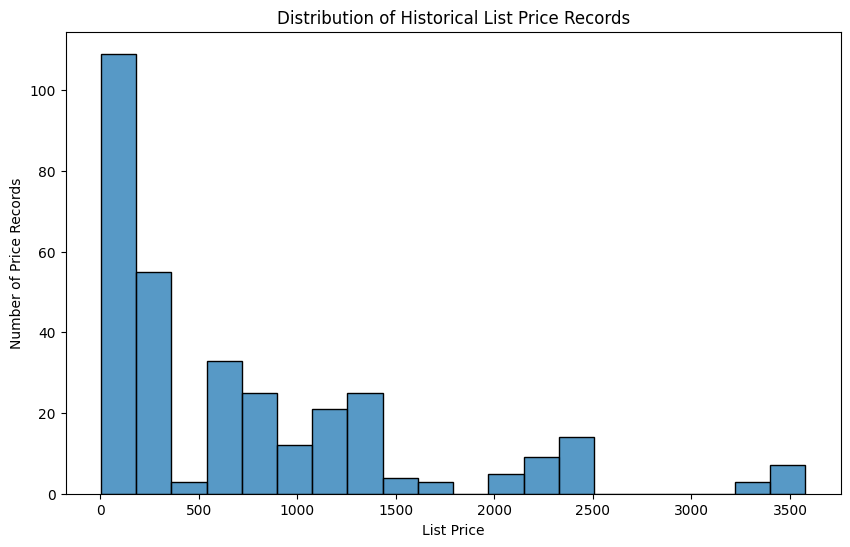

In [34]:
from matplotlib import pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.histplot(
    data=available_price_records_df,
    x="list_price",
    bins=20
)

plt.title("Distribution of Historical List Price Records")
plt.xlabel("List Price")
plt.ylabel("Number of Price Records")
plt.show()

In [ ]:
feature_1_insights = """
The first feature explored is list_price, using the cleaned price-history records with available list-price values after exact duplicate removal.

There are 328 non-missing historical list-price records. The distribution is strongly right-skewed: the median list price is approximately 360.58, while the mean is higher at approximately 740.87. This indicates that many historical price records are concentrated at lower price levels, with a smaller number of much higher-priced records pulling the average upward.

Historical list prices vary widely, from 2.29 to 3578.27. The highest observed prices occur in a small group of historical records, while most records remain well below the maximum range shown in the chart.

This feature is relevant to product clustering because list-price level can help separate low-priced products from premium products. However, the wide spread and right-skewed distribution mean that price-based features should be scaled during modelling so that high-price products do not dominate the clustering distance calculations.

"""

In [36]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### B.3 Explore Feature of Interest `effective price period`

In [37]:
# Convert effective-period dates for price-history analysis
price_history_df["start_date"] = pd.to_datetime(
    price_history_df["start_date"],
    errors="coerce"
)

price_history_df["end_date"] = pd.to_datetime(
    price_history_df["end_date"],
    errors="coerce"
)

# Missing end_date is treated as an open price-history record
price_history_df["is_open_price_record"] = price_history_df["end_date"].isna()

price_history_df["is_open_price_record"].value_counts(dropna=False)

,count
is_open_price_record,
True,200
False,195


In [38]:
price_period_summary = (
    price_history_df
    .groupby(["start_date", "is_open_price_record"], dropna=False, as_index=False)
    .agg(
        price_record_count=("product_id", "size"),
        product_count=("product_id", "nunique"),
        available_list_price_count=("list_price", "count")
    )
)

price_period_summary

,start_date,is_open_price_record,price_record_count,product_count,available_list_price_count
0,2011-05-31,False,70,70,53
1,2011-05-31,True,1,1,0
2,2012-05-30,False,121,121,105
3,2012-05-30,True,4,4,2
4,2013-05-30,True,193,193,163
5,NaT,False,4,4,3
6,NaT,True,2,2,2


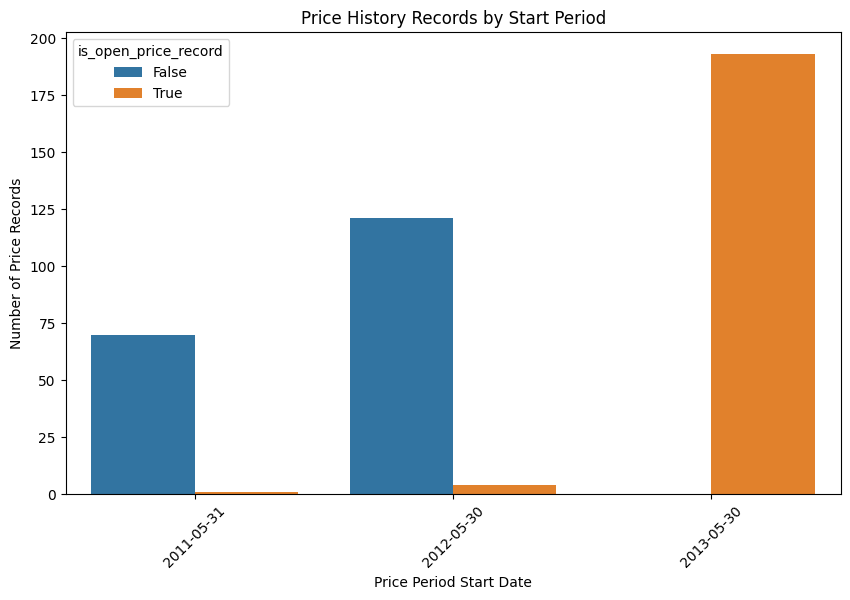

In [39]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=price_period_summary.dropna(subset=["start_date"]),
    x="start_date",
    y="price_record_count",
    hue="is_open_price_record"
)

plt.title("Price History Records by Start Period")
plt.xlabel("Price Period Start Date")
plt.ylabel("Number of Price Records")
plt.xticks(rotation=45)
plt.show()

In [ ]:
feature_2_insights = """
The second feature explored is the effective price period, using start_date and end_date to understand how list-price records are stored over time.

After duplicate removal, 200 price-history records have a missing end_date and are treated as open price records, while 195 records have a completed end_date and represent closed historical price periods. The period summary shows that most closed records begin in 2011-05-31 or 2012-05-30, whereas the largest group of open records begins in 2013-05-30.

This pattern suggests that the table stores historical list-price periods and that many later records remain open. However, the data is not perfectly clean: a small number of open records begin in earlier periods, and six records have a missing start_date. Therefore, open price records should be interpreted as available ongoing price-history records rather than assumed to be a complete current-price view for every product.

For the clustering use case, effective price periods are useful because they show whether a product has a short or longer list-price history. They also indicate that historical price features should be prepared carefully at product level before modelling."""

In [41]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### B.4 Explore Feature of Interest `product-level price history`

In [42]:
# Aggregate price-history records to one row per product
product_price_history_summary_df = (
    price_history_df
    .groupby("product_id", as_index=False)
    .agg(
        price_history_count=("product_id", "size"),
        available_list_price_count=("list_price", "count"),
        min_list_price=("list_price", "min"),
        max_list_price=("list_price", "max"),
        avg_list_price=("list_price", "mean"),
        first_price_start_date=("start_date", "min"),
        latest_price_start_date=("start_date", "max")
    )
)

product_price_history_summary_df["list_price_range"] = (
    product_price_history_summary_df["max_list_price"]
    - product_price_history_summary_df["min_list_price"]
)

product_price_history_summary_df.head()

,product_id,price_history_count,available_list_price_count,min_list_price,max_list_price,avg_list_price,first_price_start_date,latest_price_start_date,list_price_range
0,001a3a89-15cc-435e-89e5-0c844f44f595,1,1,74.9900,74.99,74.99000,2012-05-30,2012-05-30,0.0000
1,0025c2c9-855d-45a7-92ad-f4ab2fb016d1,2,2,540.7545,594.83,567.79225,2012-05-30,2012-05-30,54.0755
2,00b509f3-14e1-42ce-b59f-07b5dd91229d,1,1,1349.6000,1349.60,1349.60000,2011-05-31,2011-05-31,0.0000
3,00d697bd-e064-4e0a-8486-c04f6a4377c3,1,0,NaN,NaN,NaN,2013-05-30,2013-05-30,NaN
4,01225971-c68c-4650-8d3c-f498ece3c5da,1,1,3578.2700,3578.27,3578.27000,2011-05-31,2011-05-31,0.0000


In [43]:
product_price_history_summary_df["price_history_count"].value_counts().sort_index()

,count
price_history_count,
1,216
2,52
3,25


In [44]:
product_price_history_summary_df["list_price_range"].describe()

,list_price_range
count,253.000000
mean,22.216962
std,56.249588
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,261.787500


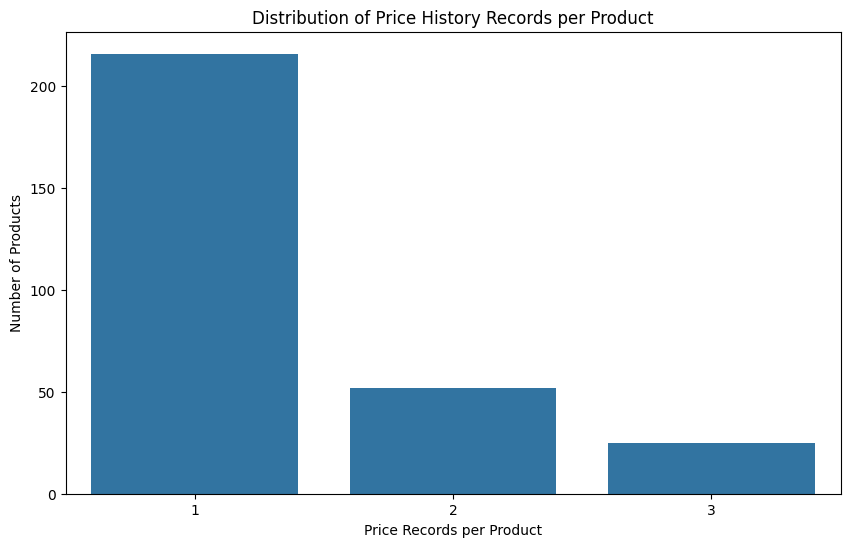

In [45]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=product_price_history_summary_df,
    x="price_history_count"
)

plt.title("Distribution of Price History Records per Product")
plt.xlabel("Price Records per Product")
plt.ylabel("Number of Products")
plt.show()

In [ ]:
feature_3_insights = """
The third feature explored is product-level price history. The cleaned price-history records were aggregated to one row per product so that record counts and observed list-price ranges can be examined at the same level required for later product clustering.

Most products have limited historical price coverage. Of the 293 products represented in the cleaned price-history table, 216 products have one price-history record, 52 products have two records, and 25 products have three records. This shows that only a smaller subset of products has multiple observed list-price periods in this extract.

The product-level list_price_range is available for 253 products with usable list-price values. Its median and upper quartile are both zero, indicating that most products with available historical prices show no observed list-price variation across their recorded price periods. However, a smaller set of products has price changes, with the largest observed range reaching approximately 261.79.

This product-level aggregation is important for the clustering use case because the raw history table contains repeated products across price periods and cannot be used directly in a one-row-per-product modelling table. Features such as price_history_count, average list price, latest available list price, and list_price_range can be considered later, but their usefulness should be judged alongside missing price-history values and sales-product coverage.
"""

In [47]:
# Do not modify this code
print_tile(size="h3", key='feature_3_insights', value=feature_3_insights)

### B.5 Contextual Integration Analysis for Sold-Product Price Coverage

In [48]:
# Load product and order-line data for contextual price-history coverage analysis
try:
    product_df = pd.read_csv(at.folder_path / "product.csv")
    sales_order_detail_df = pd.read_csv(at.folder_path / "sales_order_detail.csv")
except Exception as e:
    print(e)

print("product_list_price_history rows after duplicate removal:", len(price_history_df))
print(
    "Unique products in product_list_price_history:",
    price_history_df["product_id"].nunique()
)

print("\nproduct rows before duplicate removal:", len(product_df))
print("Unique product_id in product:", product_df["product_id"].nunique())
print("Exact duplicate product rows:", product_df.duplicated().sum())

print("\nsales_order_detail rows:", len(sales_order_detail_df))
print(
    "Unique sold products in sales_order_detail:",
    sales_order_detail_df["product_id"].nunique()
)

product_list_price_history rows after duplicate removal: 395
Unique products in product_list_price_history: 293

product rows before duplicate removal: 886
Unique product_id in product: 504
Exact duplicate product rows: 382

sales_order_detail rows: 42100
Unique sold products in sales_order_detail: 254


In [49]:
# Check coverage of sold products in product-list-price history
sold_product_ids = sales_order_detail_df["product_id"].dropna().unique()

sold_price_history_df = price_history_df[
    price_history_df["product_id"].isin(sold_product_ids)
].copy()

sold_products_with_any_price_history = (
    sold_price_history_df["product_id"].nunique()
)

sold_products_with_available_history_price = (
    sold_price_history_df.loc[
        sold_price_history_df["list_price"].notna(),
        "product_id"
    ].nunique()
)

sold_products_with_open_price_record = (
    sold_price_history_df.loc[
        sold_price_history_df["is_open_price_record"],
        "product_id"
    ].nunique()
)

sold_products_with_open_available_price = (
    sold_price_history_df.loc[
        sold_price_history_df["is_open_price_record"]
        & sold_price_history_df["list_price"].notna(),
        "product_id"
    ].nunique()
)

print("Sold products with any price-history record:", sold_products_with_any_price_history)
print("Sold products with any available historical list price:", sold_products_with_available_history_price)
print("Sold products with an open price-history record:", sold_products_with_open_price_record)
print("Sold products with an open record and available list price:", sold_products_with_open_available_price)
print("Total sold products:", len(sold_product_ids))

Sold products with any price-history record: 254
Sold products with any available historical list price: 221
Sold products with an open price-history record: 185
Sold products with an open record and available list price: 156
Total sold products: 254


In [50]:
# Remove exact duplicate product rows before product-level coverage checks
product_unique_df = product_df.drop_duplicates().copy()

sold_product_price_context_df = (
    pd.DataFrame({"product_id": sold_product_ids})
    .merge(
        product_unique_df[
            ["product_id", "name", "list_price", "standard_cost"]
        ],
        on="product_id",
        how="left",
        validate="one_to_one",
        indicator="product_join_status"
    )
)

sold_product_price_context_df["product_join_status"].value_counts(dropna=False)

,count
product_join_status,
both,254
left_only,0
right_only,0


In [51]:
print("Sold products matched to product table:",
      (sold_product_price_context_df["product_join_status"] == "both").sum())

print("Sold products with available product-table list_price:",
      sold_product_price_context_df["list_price"].notna().sum())

print("Sold products with available product-table standard_cost:",
      sold_product_price_context_df["standard_cost"].notna().sum())

Sold products matched to product table: 254
Sold products with available product-table list_price: 254
Sold products with available product-table standard_cost: 228


In [52]:
# Compare price-information coverage for sold products
sold_price_coverage_df = pd.DataFrame({
    "price_information_source": [
        "Any price-history record",
        "Any available history list price",
        "Open price-history record",
        "Open history record with list price",
        "Product table list price"
    ],
    "sold_product_count": [
        sold_products_with_any_price_history,
        sold_products_with_available_history_price,
        sold_products_with_open_price_record,
        sold_products_with_open_available_price,
        sold_product_price_context_df["list_price"].notna().sum()
    ]
})

sold_price_coverage_df["coverage_pct"] = (
    sold_price_coverage_df["sold_product_count"]
    / len(sold_product_ids)
    * 100
).round(2)

sold_price_coverage_df

,price_information_source,sold_product_count,coverage_pct
0,Any price-history record,254,100.00
1,Any available history list price,221,87.01
2,Open price-history record,185,72.83
3,Open history record with list price,156,61.42
4,Product table list price,254,100.00


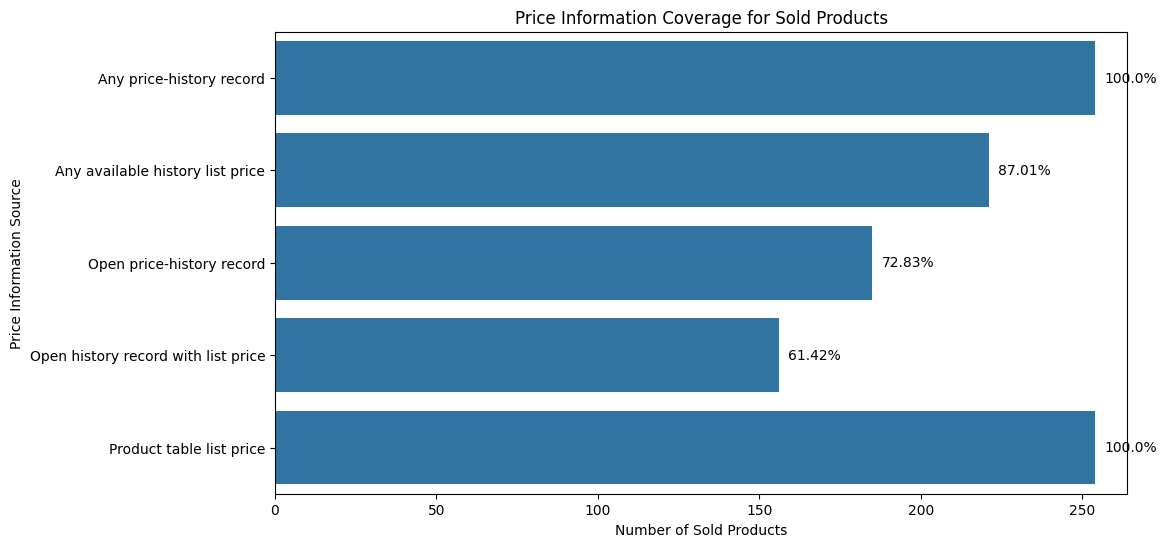

In [53]:
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=sold_price_coverage_df,
    x="sold_product_count",
    y="price_information_source"
)

plt.title("Price Information Coverage for Sold Products")
plt.xlabel("Number of Sold Products")
plt.ylabel("Price Information Source")
plt.xlim(0, len(sold_product_ids) + 10)

for index, row in sold_price_coverage_df.iterrows():
    ax.text(
        row["sold_product_count"] + 3,
        index,
        f'{row["coverage_pct"]}%',
        va="center"
    )

plt.show()

In [55]:
price_history_integration_insights = """
The cleaned product_list_price_history table was compared with sales_order_detail and product to assess whether historical list-price information is suitable for the sold-product clustering use case.

The sales_order_detail table contains 254 unique sold products. All 254 sold products have at least one record in product_list_price_history, so the history table has complete product-id coverage for sold products. However, usable historical price coverage is lower. Only 221 sold products have at least one non-missing historical list_price, 185 have an open price-history record, and 156 have an open price-history record with an available list_price.

The product table provides stronger product-level list-price coverage for modelling. After removing exact duplicate product rows, all 254 sold products match to product and all 254 have a non-missing product-table list_price. Therefore, product list_price is a better candidate for a broad product-level price feature, while product_list_price_history is more suitable for derived historical features such as price_history_count, average historical list price, and observed list_price_range.

This integration analysis supports careful feature preparation for clustering. The historical price table should be aggregated to one row per product before joining to the modelling dataset, and its derived price-history features should be used with awareness of missing values and incomplete open-price coverage.
"""

In [56]:
# Do not modify this code
print_tile(size="h3", key='price_history_integration_insights', value=price_history_integration_insights)